# Урок 4. Метрики качества классификации ч.2

Продолжим работу с метриками классификации. В предыдущем задании мы разобрали матрицу ошибок и две основные метрики, которые используются при бинарной классификации.

Сейчас рассмотрим F-меру - совокупную метрику по precision и recall - и более сложную AUC-ROC.

### 2.1
Из задания к предыдущему уроку выберите классификатор, который давал наименьшее значение recall, вычислите для него precision, применив precision_score, и самостоятельно посчитайте F1-меру (расчеты должны присутствовать). Затем проверьте ответ, используя встроенную функцию.

Сравните полученную f1-меру со значением среднего арифметического полноты и точности.

In [1]:
from sklearn.metrics import precision_score, f1_score
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, recall_score

titanic_train = pd.read_csv('data/train.csv')
median = titanic_train.groupby('Sex')['Age'].median()

# 2. Заменяем пропущенные значения Age на медиану по полу
titanic_train['Age'] = titanic_train.apply(
    lambda row: median[row['Sex']] if pd.isna(row['Age']) else row['Age'],
    axis=1
)

# 3. Заменяем пропущенные значения в Cabin и Embarked на 'U'
titanic_train[['Cabin', 'Embarked']] = titanic_train[['Cabin', 'Embarked']].fillna('U')

# 🔄 Заменим значения в колонке Sex
titanic_train['Sex'] = titanic_train['Sex'].map({'male': 0, 'female': 1})

# 🔄 Заменим значения в колонке Embarked
titanic_train['Embarked'] = titanic_train['Embarked'].map({'U': 0, 'S': 1, 'C': 2, 'Q': 3})

# 🧹 Удалим лишние колонки
titanic_train = titanic_train.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'])

x_train, x_test, y_train, y_test = train_test_split(titanic_train.iloc[:,1:],
                                                    titanic_train['Survived'],
                                                    test_size=0.25,
                                                    random_state=17)

nb = GaussianNB()
nb.fit(x_train, y_train)
nb_predict = nb.predict(x_test)


dtc = DecisionTreeClassifier(random_state=17)
dtc.fit(x_train, y_train)
dtc_predictions = dtc.predict(x_test)

lr = LogisticRegression(random_state=17)
lr.fit(x_train, y_train)
lr_predictions = lr.predict(x_test)

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(x_train, y_train)
knn_predictions = knn.predict(x_test)
cm_knn = confusion_matrix(y_test, knn_predictions)
recall_knn_my = cm_knn[0, 0]/(cm_knn[0, 0] + cm_knn[0, 1])
recall_knn = recall_score(y_test, knn_predictions)
precision_knn = precision_score(y_test, knn_predictions)
print("recall_knn_my: ", recall_knn_my)
print("recall_knn: ", recall_knn)
print("precision_knn: ", precision_knn)

recall_knn_my:  0.8396946564885496
recall_knn:  0.4891304347826087
precision_knn:  0.6818181818181818


In [3]:
### YOUR CODE HERE ###
f1_my = 2 * precision_knn * recall_knn / (precision_knn + recall_knn)
print("f1_my: ", f1_my)

f1 = f1_score(y_test, knn_predictions)
print("f1: ", f1)

sred = (recall_knn + precision_knn)/2
print("sred: ", sred)



f1_my:  0.5696202531645569
f1:  0.569620253164557
sred:  0.5854743083003953


В библиотеке sklearn есть удобная функция classification_report, возвращающая precision, recall, F-меру и количество экземпляров каждого класса в удобном для чтения формате. Также существует функция precision_recall_fscore_support, возвращающая те же самые метрики, но в форме массива.

### 2.2
Для каждого классификатора из предыдущего урока рассчитайте и выведите следующие импортированные метрики.

In [5]:
from sklearn.metrics import precision_recall_fscore_support, classification_report

In [6]:
### YOUR CODE HERE ###
knn_rep1 = precision_recall_fscore_support(y_test, knn_predictions)
print("knn_rep1: ", knn_rep1)
knn_rep2 = classification_report(y_test, knn_predictions)
print("knn_rep2: ", knn_rep2)

nb_rep1 = precision_recall_fscore_support(y_test, nb_predict)
nb_rep2 = classification_report(y_test, nb_predict)
print("nb_rep1: ", nb_rep1)
print("nb_rep2: ", nb_rep2)

dtc_rep1 = precision_recall_fscore_support(y_test, dtc_predictions)
dtc_rep2 = classification_report(y_test, dtc_predictions)
print("dtc_rep1: ", dtc_rep1)
print("dtc_rep2: ", dtc_rep2)

lr_rep1 = precision_recall_fscore_support(y_test, lr_predictions)
lr_rep2 = classification_report(y_test, lr_predictions)
print("lr_rep1: ", lr_rep1)
print("lr_rep2: ", lr_rep2)



knn_rep1:  (array([0.70063694, 0.68181818]), array([0.83969466, 0.48913043]), array([0.76388889, 0.56962025]), array([131,  92]))
knn_rep2:                precision    recall  f1-score   support

           0       0.70      0.84      0.76       131
           1       0.68      0.49      0.57        92

    accuracy                           0.70       223
   macro avg       0.69      0.66      0.67       223
weighted avg       0.69      0.70      0.68       223

nb_rep1:  (array([0.80434783, 0.76470588]), array([0.84732824, 0.70652174]), array([0.82527881, 0.73446328]), array([131,  92]))
nb_rep2:                precision    recall  f1-score   support

           0       0.80      0.85      0.83       131
           1       0.76      0.71      0.73        92

    accuracy                           0.79       223
   macro avg       0.78      0.78      0.78       223
weighted avg       0.79      0.79      0.79       223

dtc_rep1:  (array([0.8115942 , 0.77647059]), array([0.85496183, 0.

Вернемся к классификатору LogisticRegression, который мы обучали в предыдущем задании. Там мы не затрагивали настройку гиперпараметров: сделать это можно с помощью LogisticRegressionCV - перебора параметров по сетке с последующей кросс-валидацией (по сути это аналог GridSearchCV, но со своими параметрами внутри, применимыми только к логистической регрессии). Этот класс создан специально для логистической регрессии, т.к. для нее известны эффективные алгоритмы перебора параметров.

У LogisticRegression есть гиперпараметр C - обратный коэффициент регуляризации. Не вдаваясь в подробное описание по формуле, можно сказать, что C соответствует "сложности" модели: чем больше C, тем более сложные зависимости может восстанавливать модель; если параметр C слишком мал (слишком сильная регуляризация), то модель окажется недообученной, а если наоборот регуляризация слишком слабая (т.е. C принимает большие значения), то скорее всего модель окажется переобученной, потому как модель будет слишком "бояться" ошибиться на обучающей выборке.

### 2.3

1. Используя StratifiedKFold, разбейте данные для кросс-валидации по 5-ти блокам (не забывайте во всех методах использовать random_state=17).
2. С помощью numpy.logspace разбейте интервал (-1, 2) на 500 значений.
3. С помощью LogisticRegressionCV подберите оптимальный параметр C: установите гиперпараметр Cs равным объекту из п.2 (разбиение интервала (-1, 2) отвечает за подбор обратного коэффициента регуляризации C); cv равным объекту из п.1 (разбиение для кросс-валидации); scoring равным "roc_auc" (отвечает за оптимизацию гиперпараметров на кросс-валидации: метрика, установленная в scoring, контролирует, как оценивать модель при каждом из наборе параметров, т.е. показывает, какая метрика должна быть наилучшей).
4. Обучите полученную модель на тренировочных данных.

In [8]:
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegressionCV
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
import numpy as np

In [9]:
### YOUR CODE HERE ###
# === 2. StratifiedKFold с 5 блоками ===
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=17)

# === 3. Разбиение интервала (-1, 2) на 500 значений логарифмически ===
C_values = np.logspace(-1, 2, 500)

# === 4. LogisticRegressionCV с подбором C и метрикой roc_auc ===
model = make_pipeline(
    StandardScaler(),
    LogisticRegressionCV(
        Cs=C_values,
        cv=cv,
        scoring='roc_auc',
        max_iter=1000,
        random_state=17
    )
)

# === 5. Обучение модели ===
model.fit(x_train, y_train)

best_C = model.named_steps['logisticregressioncv'].C_[0]
print(f"Лучшее значение C по ROC AUC: {best_C:.5f}")

Лучшее значение C по ROC AUC: 11.06848


### 2.4
Используя метод plot из matplotlib.pyplot, выведите график зависимости auc_roc от значения C.

*Примечание: значения по оси x - разбиение с помощью np.logspace из п.2 предыдущего задания, а значения по оси y - среднее значение roc_auc по каждой валидации, т.е. среднее значение из полученных на каждом из 5-ти разбиений при данном параметре C (используйте метод scores_ объекта, который инкапсулирует LogisticRegressionCV).*

In [11]:
import matplotlib.pyplot as plt

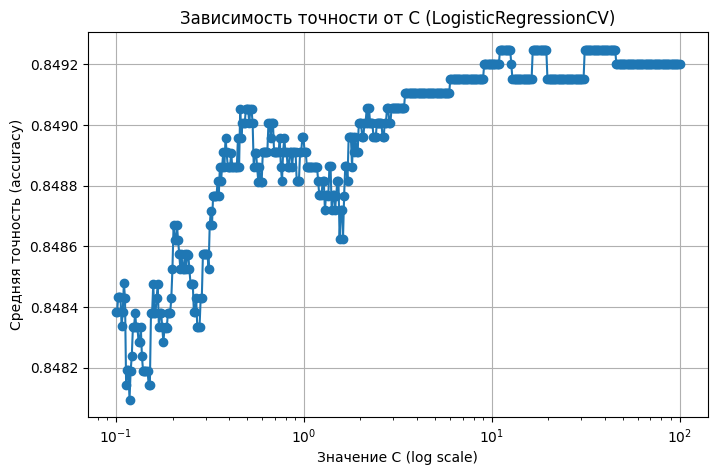

Лучшее значение C: 11.06848488549412


In [12]:
### YOUR CODE HERE ###

# Извлекаем модель из пайплайна
logreg_cv = model.named_steps['logisticregressioncv']

# Получаем средние значения точности на каждом C (по всем фолдам)
mean_scores = logreg_cv.scores_[1].mean(axis=0)  # Класс "1" — положительный

# Строим график
plt.figure(figsize=(8, 5))
plt.semilogx(logreg_cv.Cs_, mean_scores, marker='o')
plt.xlabel("Значение C (log scale)")
plt.ylabel("Средняя точность (accuracy)")
plt.title("Зависимость точности от C (LogisticRegressionCV)")
plt.grid(True)
plt.show()




### 2.5
С помощью метода C_ того же объекта выведите лучшее значение C. Выведите более конкретную область графика (область ~15 точкам по x), включающую лучшее значение C.

*Примечание: используйте plt.xlim.*

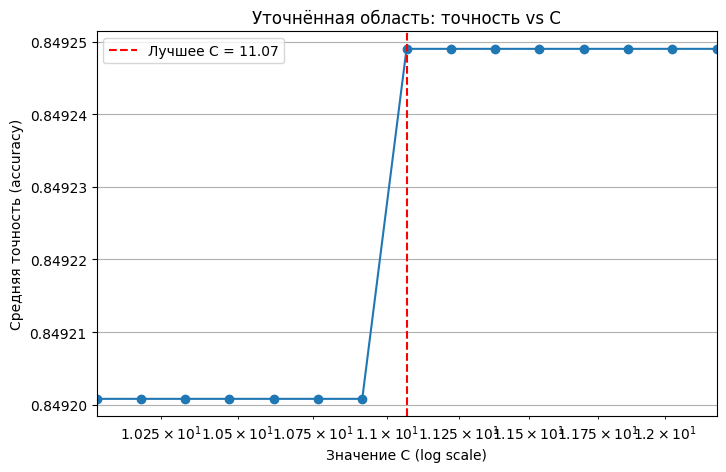

In [13]:
### YOUR CODE HERE ###
# Значения C
C_values = logreg_cv.Cs_

# Находим индекс лучшего C
best_C = logreg_cv.C_[0]
best_index = np.where(C_values == best_C)[0][0]

# Определим границы отображения — около 7 значений слева и 7 справа от лучшего
start = max(best_index - 7, 0)
end = min(best_index + 8, len(C_values))  # +8 потому что срез не включает правую границу

# Отфильтрованные значения
C_zoom = C_values[start:end]
score_zoom = mean_scores[start:end]

# Строим график с фокусом на этой области
plt.figure(figsize=(8, 5))
plt.semilogx(C_zoom, score_zoom, marker='o')
plt.xlabel("Значение C (log scale)")
plt.ylabel("Средняя точность (accuracy)")
plt.title("Уточнённая область: точность vs C")
plt.grid(True)

# Установка ограничений по оси X
plt.xlim(C_zoom[0], C_zoom[-1])

# Отмечаем лучшую точку
plt.axvline(best_C, color='red', linestyle='--', label=f"Лучшее C = {best_C:.4g}")
plt.legend()

plt.show()

### 2.6
С помощью метода predict_proba получите вероятности принадлежности объектов тестовой выборки к классам. Постройте график roc_auc для тестовой выборки и выведите значение auc.

**Пример** построения графика.

In [14]:
from sklearn.metrics import roc_auc_score, roc_curve

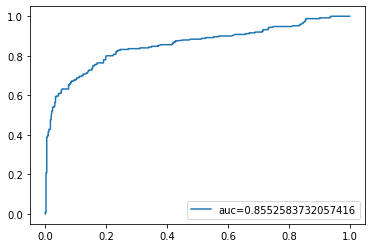

In [ ]:
probas = logit_search.fit(x_train, y_train).predict_proba(x_train)
fpr, tpr, _ = roc_curve(y_train, probas[:, 1])
auc = roc_auc_score(y_train, probas[:, 1])
plt.plot(fpr, tpr, label="auc=" + str(auc))
plt.legend(loc=4)

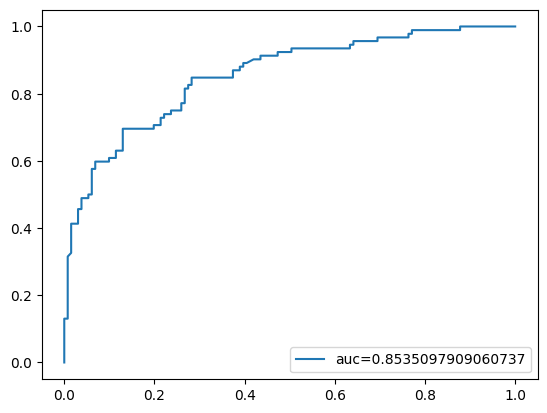

In [15]:
### YOUR CODE HERE ###

# Получаем вероятности принадлежности к классу 1
y_proba = model.predict_proba(x_test)[:, 1]  # Только столбец с вероятностями класса 1

# Вычисляем точки ROC-кривой
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)
plt.plot(fpr, tpr, label="auc=" + str(auc))
plt.legend(loc=4)

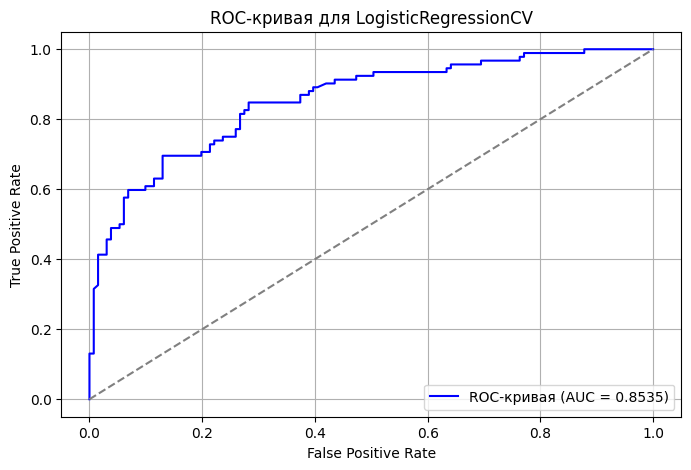

AUC на тестовой выборке: 0.8535097909060737


In [16]:
from sklearn.metrics import auc

roc_auc = auc(fpr, tpr)

# Строим график GPT!
plt.figure(figsize=(8, 5))
plt.plot(fpr, tpr, color='blue', label=f"ROC-кривая (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # линия случайной модели
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-кривая для LogisticRegressionCV")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# Выводим значение AUC
print("AUC на тестовой выборке:", roc_auc)